In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [2]:
plot_colors = {
    "psd": "xkcd:greyish",  
    "lorentzian": "xkcd:scarlet", 
    "finite_time_correction": "xkcd:dark yellow", 
    "nonstationary_correction": "xkcd:olive", 
    "total_correction": "xkcd:bright orange", 
    "non_overlapping_window": "xkcd:blue/green", 
    "overlapping_window": "xkcd:navy green"
}

plot_labels = {
    "psd": "Periodogram",
    "lorentzian": "Analytical Lorentzian",
    "finite_time_correction": "Finite-Time Correction",
    "nonstationary_correction": "Non-Stationary Correction",
    "total_correction": "Corrected PSD",
    "non_overlapping_window": "Non-Overlapping Windows",
    "overlapping_window": "Overlapping Windows",
    "hann_window": "Hanning Window",
    "boxcar_window": "Boxcar Window",
    "bartlett_window": "Bartlett Window"
}

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

fontsize=14

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 

    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 17,
    'axes.linewidth': 1.0,
    'axes.edgecolor': 'black',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'grid.linewidth': 0.75,
    'lines.linewidth': 1.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

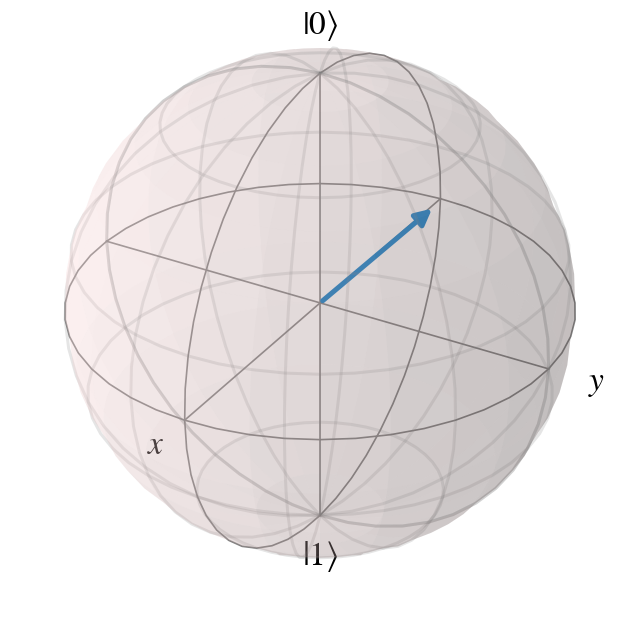

In [28]:
b = qt.Bloch()
b.vector_color = ['tab:blue']
up = (1 * qt.basis(2, 0) + 0.4*np.exp(1j * 1.5*np.pi / 4) * qt.basis(2, 1)).unit()
b.add_states(up)
b.show()
b.save("bloch_sphere.pdf", format='pdf')

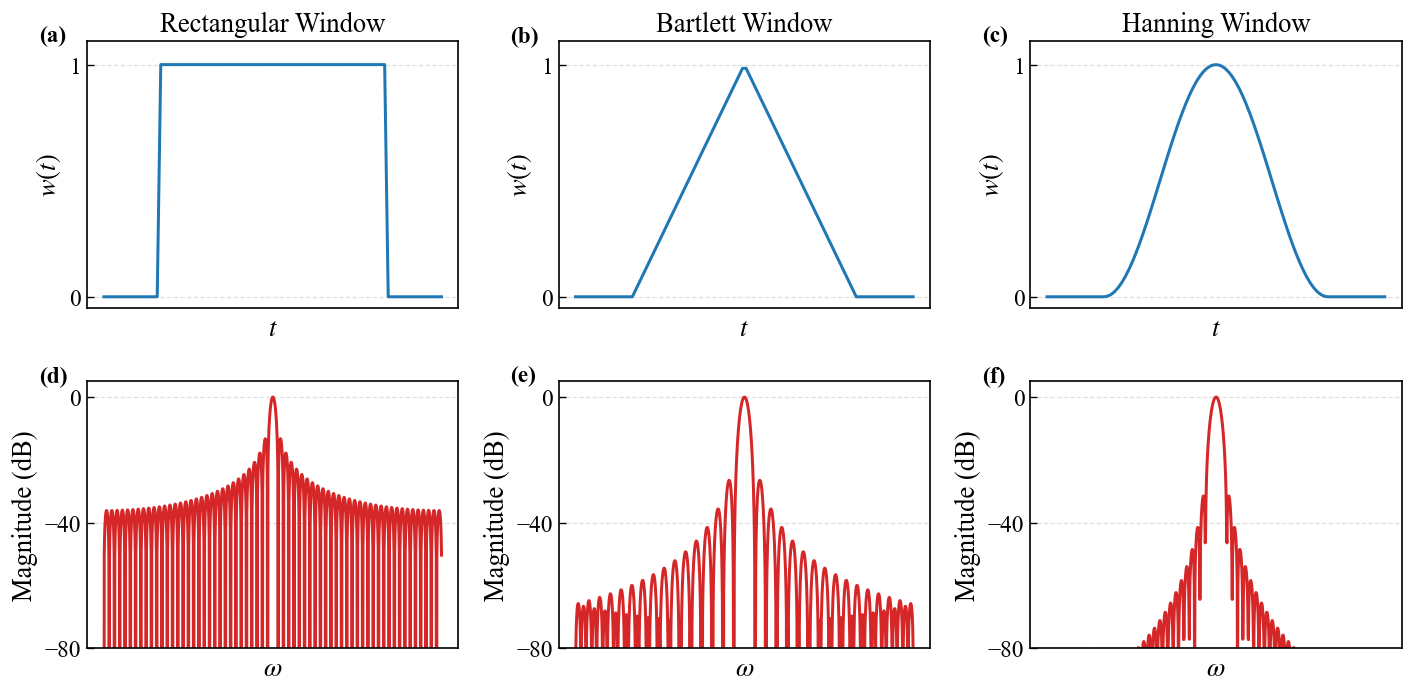

In [ ]:
N = 64           
pad = 16        
n = np.arange(N + 2 * pad)
windows = {
    "Rectangular Window": np.ones(N),
    "Bartlett Window": np.bartlett(N),
    "Hanning Window": np.hanning(N),
}
NFFT = 1024
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, (name, w) in enumerate(windows.items()):
    w_padded = np.concatenate([np.zeros(pad), w, np.zeros(pad)])

    ax_t = axes[0, i]
    ax_t.plot(n, w_padded, color='tab:blue')
    ax_t.set_title(name)
    ax_t.set_xlabel("$t$")
    ax_t.set_ylabel("$w(t)$")
    ax_t.set_xticks([])
    ax_t.set_yticks([0, 1])
    ax_t.set_ylim(-0.05, 1.1)
    ax_f = axes[1, i]
    W = np.fft.fft(w, NFFT)
    W = np.fft.fftshift(W)
    mag = 20 * np.log10(np.abs(W) / np.max(np.abs(W)) + 1e-12)
    freq = np.linspace(-0.5, 0.5, NFFT)
    ax_f.plot(freq, mag, color='tab:red')
    ax_f.set_xlabel("$\omega$")
    ax_f.set_ylabel("Magnitude (dB)")
    ax_f.set_xticks([])
    ax_f.set_yticks([-80, -40, 0])
    ax_f.set_ylim(-80, 5)
abc = ['a', 'b', 'c', 'd', 'e', 'f']
for i, ax in enumerate(axes.flatten()):
    ax.text(
    -0.13, 1.06, f"({abc[i]})",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=fontsize,
    fontweight="bold"
    )
plt.tight_layout()
plt.savefig("../figures/explanatory/window_functions.pdf", bbox_inches='tight')

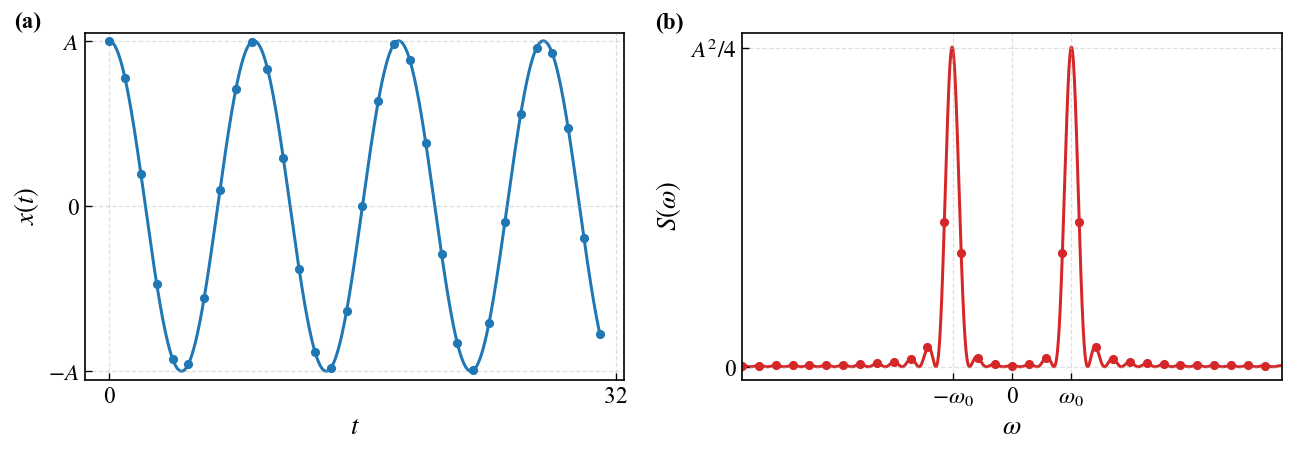

In [ ]:
A = 1.0
N = 32
w0 = 2 * np.pi * 0.109375
n = np.arange(N)
x = A * np.cos(w0 * n)

n_fine = np.linspace(0, N - 1, 2000)
x_fine = A * np.cos(w0 * n_fine)

NFFT = 4096
X_smooth = np.fft.fftshift(np.fft.fft(x, NFFT))
omega_smooth = np.fft.fftshift(np.fft.fftfreq(NFFT)) * 2 * np.pi
P_smooth = (np.abs(X_smooth) ** 2) / N**2
X_dft = np.fft.fftshift(np.fft.fft(x, N))
omega_dft = np.fft.fftshift(np.fft.fftfreq(N)) * 2 * np.pi
P_dft = (np.abs(X_dft) ** 2) / N**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax_t = axes[0]
ax_t.plot(n_fine, x_fine, color='tab:blue', zorder=1)
ax_t.scatter(n, x, color='tab:blue', s=20, zorder=2, label=f"$N={N}$ samples")
ax_t.set_xlabel(r"$t$")
ax_t.set_ylabel(r"$x(t)$")
ax_t.set_xticks([0 ,32])
ax_t.set_yticks([-A, 0, A])
ax_t.set_yticklabels([r"$-A$", "0", r"$A$"])
ax_t.set_ylim(-1.05 * A, 1.05 * A)

ax_f = axes[1]
ax_f.plot(omega_smooth, P_smooth, color='tab:red', zorder=1)
ax_f.scatter(omega_dft, P_dft, color='tab:red', s=20, zorder=2, label=f"$N={N}$ DFT bins")
ax_f.set_xlabel(r"$\omega$")
ax_f.set_ylabel(r"$S(\omega)$")
ax_f.set_xticks([-w0, 0, w0])
ax_f.set_xticklabels([r"$-\omega_0$", "0", r"$\omega_0$"])
ax_f.set_yticks([0, A**2 / 4])
ax_f.set_yticklabels(["0", r"$A^2/4$"])
ax_f.set_xlim(-np.pi, np.pi)
ax_f.set_ylim(-0.01, A**2 / 4 * 1.05)

ax_t.text(
    -0.13, 1.06, "(a)",
    transform=ax_t.transAxes,
    ha="left",
    va="top",
    fontsize=fontsize,
    fontweight="bold"
)

ax_f.text(
    -0.16, 1.06, "(b)",
    transform=ax_f.transAxes,
    ha="left",
    va="top",
    fontsize=fontsize,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("../figures/explanatory/spectral_leakage.pdf", bbox_inches='tight')

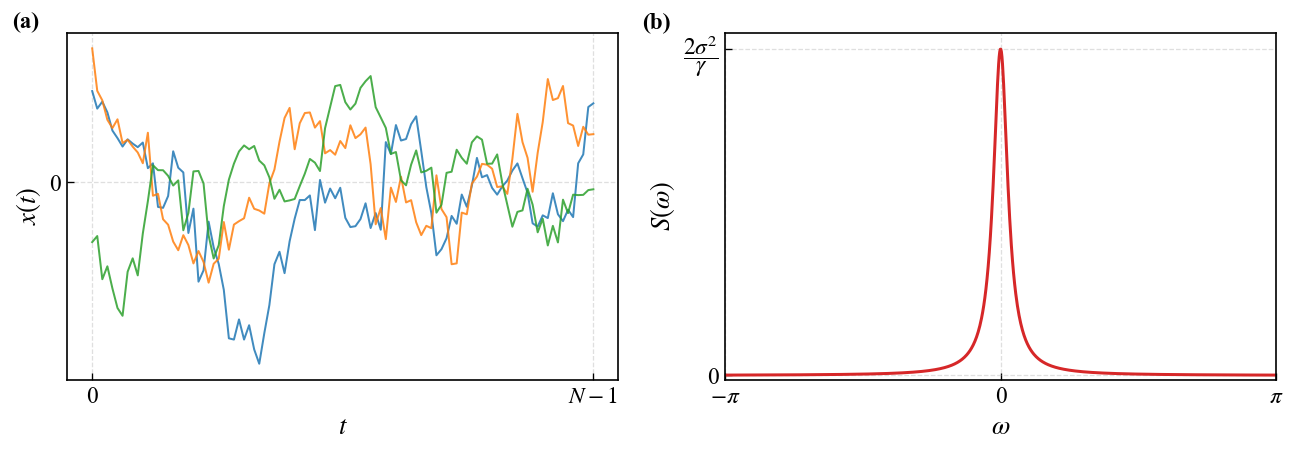

In [ ]:
from nonstationarynoise.ornstein_uhlenbeck import sample_stationary_ou

N_steps = 100
dt = 1.0
gamma = 0.1
alpha = 1.0
n_traj = 3

t = np.arange(N_steps) * dt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax_traj = axes[0]

for i in range(n_traj):
    x = sample_stationary_ou(N_steps, gamma, alpha, dt)
    ax_traj.plot(t, x, linewidth=1.2, alpha=0.85)

ax_traj.set_xlabel(r"$t$")
ax_traj.set_ylabel(r"$x(t)$")
ax_traj.set_xticks([0, 99])
ax_traj.set_xticklabels([0, "$N-1$"])
ax_traj.set_yticks([0])

ax_psd = axes[1]

omega = np.linspace(-np.pi, np.pi, 1000)
S = (2 * gamma * alpha**2) / (gamma**2 + (omega / dt)**2)
S0 = (2 * alpha**2) / gamma

ax_psd.plot(omega, S, color='tab:red')
ax_psd.set_xlabel(r"$\omega$")
ax_psd.set_ylabel(r"$S(\omega)$")
ax_psd.set_xticks([-np.pi, 0, np.pi])
ax_psd.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
ax_psd.set_yticks([0, S0])
ax_psd.set_yticklabels(["0", r"$\dfrac{2\sigma^2}{\gamma}$"])
ax_psd.set_xlim(-np.pi, np.pi)
ax_psd.set_ylim(-0.25, S0 * 1.05)

ax_traj.text(
    -0.10, 1.06, "(a)",
    transform=ax_traj.transAxes,
    ha="left",
    va="top",
    fontsize=fontsize,
    fontweight="bold"
)

ax_psd.text(
    -0.15, 1.06, "(b)",
    transform=ax_psd.transAxes,
    ha="left",
    va="top",
    fontsize=fontsize,
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("../figures/explanatory/ou_process.pdf", bbox_inches='tight')

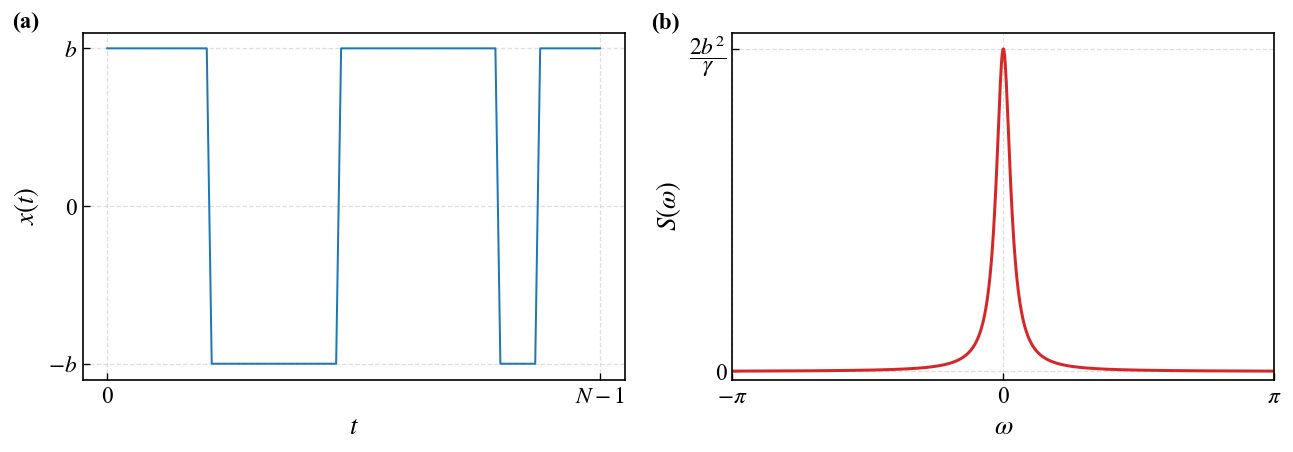

In [ ]:
from nonstationarynoise.oneoverf import sample_one_over_f

N_steps = 100
N_tlf = 1
gamma = 0.1
sigma = 1.0
z = 0
dt = 1.0

t = np.arange(N_steps) * dt
x = sample_one_over_f(N_steps, N_tlf, gamma, gamma, sigma, z, dt)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax_traj = axes[0]
ax_traj.plot(t, x, color='tab:blue', linewidth=1.2)
ax_traj.set_xlabel(r"$t$")
ax_traj.set_ylabel(r"$x(t)$")
ax_traj.set_xticks([0, 99])
ax_traj.set_xticklabels([0, "$N-1$"])
ax_traj.set_yticks([-sigma, 0, sigma])
ax_traj.set_yticklabels([r"$-b$", "0", r"$b$"])

ax_psd = axes[1]

omega = np.linspace(-np.pi, np.pi, 1000)
S = (2 * sigma**2 * gamma) / (gamma**2 + omega**2)
S0 = 2 * sigma**2 / gamma

ax_psd.plot(omega, S, color='tab:red')
ax_psd.set_xlabel(r"$\omega$")
ax_psd.set_ylabel(r"$S(\omega)$")
ax_psd.set_xticks([-np.pi, 0, np.pi])
ax_psd.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
ax_psd.set_yticks([0, S0])
ax_psd.set_yticklabels(["0", r"$\dfrac{2b^2}{\gamma}$"])
ax_psd.set_xlim(-np.pi, np.pi)
ax_psd.set_ylim(-0.5, S0 * 1.05)

ax_traj.text(
    -0.13, 1.06, "(a)",
    transform=ax_traj.transAxes,
    ha="left",
    va="top",
    fontsize=fontsize,
    fontweight="bold"
)

ax_psd.text(
    -0.15, 1.06, "(b)",
    transform=ax_psd.transAxes,
    ha="left",
    va="top",
    fontsize=fontsize,
    fontweight="bold"
)


plt.tight_layout()
plt.savefig('../figures/explanatory/single_tlf.pdf', bbox_inches='tight')

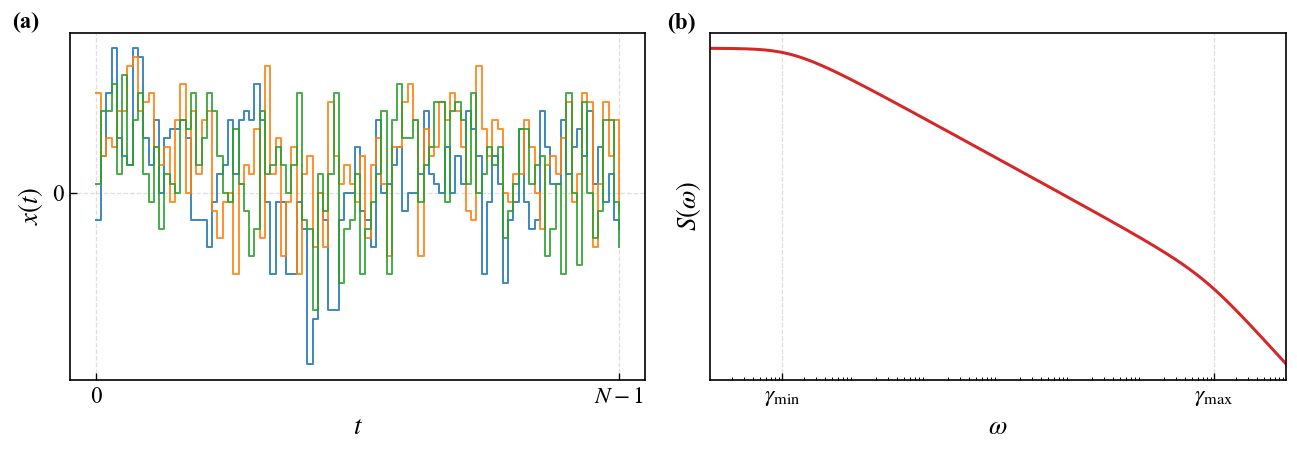

In [ ]:
N_steps = 100
gamma_min = 1e-3
gamma_max = 1e3
ratio = np.log(gamma_max / gamma_min)
N_tlf = 200
sigma = 1.0
z = 1.0
dt = 1.0
n_traj = 3
t = np.arange(N_steps) * dt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax_traj = axes[0]
for i in range(n_traj):
    x = sample_one_over_f(N_steps, N_tlf, gamma_min, gamma_max, sigma, z, dt)
    ax_traj.step(t, x, linewidth=1.2, alpha=0.85, where='post')
ax_traj.set_xlabel(r"$t$")
ax_traj.set_ylabel(r"$x(t)$")
ax_traj.set_xticks([0, 99])
ax_traj.set_xticklabels([0, "$N-1$"])
ax_traj.set_yticks([0])

ax_psd = axes[1]

omega = np.logspace(np.log10(gamma_min / 10), np.log10(gamma_max * 10), 1000)

S = (2 * sigma**2 / (omega * ratio)) * (
    np.arctan(omega / gamma_min) - np.arctan(omega / gamma_max)
)

ax_psd.plot(omega, S, color='tab:red')
ax_psd.set_xscale('log')
ax_psd.set_yscale('log')
ax_psd.set_xlabel(r"$\omega$")
ax_psd.set_ylabel(r"$S(\omega)$")
ax_psd.set_xticks([gamma_min, gamma_max])
ax_psd.set_xticklabels([r"$\gamma_{\min}$", r"$\gamma_{\max}$"])
ax_psd.set_yticks([])
ax_psd.set_xlim(omega[0], omega[-1])

ax_traj.text(
    -0.10, 1.06, "(a)",
    transform=ax_traj.transAxes,
    ha="left",
    va="top",
    fontsize=fontsize,
    fontweight="bold"
)

ax_psd.text(
    -0.075, 1.06, "(b)",
    transform=ax_psd.transAxes,
    ha="left",
    va="top",
    fontsize=fontsize,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig('../figures/explanatory/tlf_bath.pdf', bbox_inches='tight')